In [1]:
import pandas as pd
import numpy as np

import xarray as xr
import geopandas as gpd
import rioxarray as rxr
from shapely.geometry import mapping
import matplotlib.pyplot as plt

In [14]:
class DataLoader:
    ''' Class for loading climate data from differen sources and bring them in the desired format.
    For adding new methods: The result should be a xarray timeseries for your area of interest,
    for one scenario/model/variable combination.'''

    def crop_to_park_boundary(self, nc, boundary, variable):
        ''' Takes an xarray object and crops within the provided boundary (geopandas), returning a clipped xarray object. '''
        # Select just the variable (time_bnds doesn't have spatial dims)
        nc = nc[variable].rio.set_spatial_dims(x_dim="lon", y_dim="lat")
        nc = nc.rio.write_crs("EPSG:4326", inplace=True)
        if nc.rio.crs != boundary.crs:
            boundary = boundary.to_crs(nc.rio.crs)
        nc_clipped = nc.rio.clip(boundary.geometry.values, boundary.crs, drop=True, all_touched=True)

        return(nc_clipped)

    def load_isimip(self, scenario, model, variable, boundary):
        ''' Loads data from ISIMIP 3b. This data has alsoready been downloaded, and cropped to the area of interest,
        using bash and CDO. The scripts are in this repository. The data is founds in isimip/data/processed'''
        nc = xr.open_dataset(f'isimip/data/processed/{model}_w5e5_{scenario}_{variable}_jotr_monthly.nc', engine="netcdf4")
        nc_clipped = self.crop_to_park_boundary(nc, boundary, variable).mean(("lon", "lat"))

        return nc_clipped


In [53]:
class ClimateFutures:
    ''' This class contains all the functions to create climate future datasets'''

    def __init__(self, models, scenarios, park, baseline_period):
        self.loader = DataLoader()
        self.models = models
        self.scenarios = scenarios
        self.park = park
        self.boundary = gpd.read_file(f'boundaries/{park}.shp')
        self.baseline_period = baseline_period

    def calculate_anomaly(self, scenario, baseline_period, model, variable, boundary):
        ''' Takes a clipped xarray object and calculates the anomaly relative to the provided baseline period. 
        Returns an xarray object of the anomaly. '''

        nc = self.loader.load_isimip(scenario, model, variable, boundary)
        nc_hist = self.loader.load_isimip("historical", model, variable, boundary)
        baseline = nc_hist.sel(time=slice(baseline_period[0], baseline_period[1])).mean("time")
        anomaly = nc - baseline

        return(anomaly)
    
    def plot_timeseries(self, ax, scenario, model, baseline_period, boundary, variable):

        if scenario == "historical":
                color = "blue"
        elif scenario == "ssp126":
            color = "#ffd580"  # light orange
        elif scenario == "ssp370":
            color = "#ff9900"  # dark orange
        elif scenario == "ssp585":
            color = "#e95462"  # red
        else:
            color = "gray"
            
        anomaly = self.calculate_anomaly(scenario, baseline_period, model, variable, boundary)
        anomaly_smooth = anomaly.rolling(time=36, center=True, min_periods=1).mean()
        plot = anomaly_smooth.plot(ax=ax, label=f"{model.split('_')[0]} {scenario}", color=color, alpha=1)
        
        return(plot)

    def plot_ensemble(self, variable):

        fig, ax = plt.subplots(figsize=(14, 6))

        for model in self.models:
            for scenario in self.scenarios:
                self.plot_timeseries(ax, scenario, model, self.baseline_period, self.boundary, variable)
        

        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_title(f'Anomaly (relative to 1979-2012) by Model and Scenario for {variable}')
        ax.set_ylabel('Anomaly')
        plt.tight_layout()
        plt.show() 

    def mid_century_anomalies(self, scenario, baseline_period, model, variable, boundary):
        anomaly = self.calculate_anomaly(scenario, baseline_period, model, variable, boundary)
        mid_century_anomaly = anomaly.sel(time=slice("2035", "2065")).mean("time")
        
        return(mid_century_anomaly)
    
    def classify(self):
        all_data = []
        for model in self.models:
            for scenario in self.scenarios:
                anomaly_tas = self.mid_century_anomalies(scenario, self.baseline_period, model, 'tas', self.boundary)
                anomaly_pr = self.mid_century_anomalies(scenario, self.baseline_period, model, 'pr', self.boundary)
                data = {
                    'model': model,
                    'scenario': scenario,
                    'park': self.park,
                    'anomaly_tas': anomaly_tas.item(),
                    'anomaly_pr': anomaly_pr.item()
                    }

                all_data.append(data)

        df = pd.DataFrame(all_data)

        return df
    

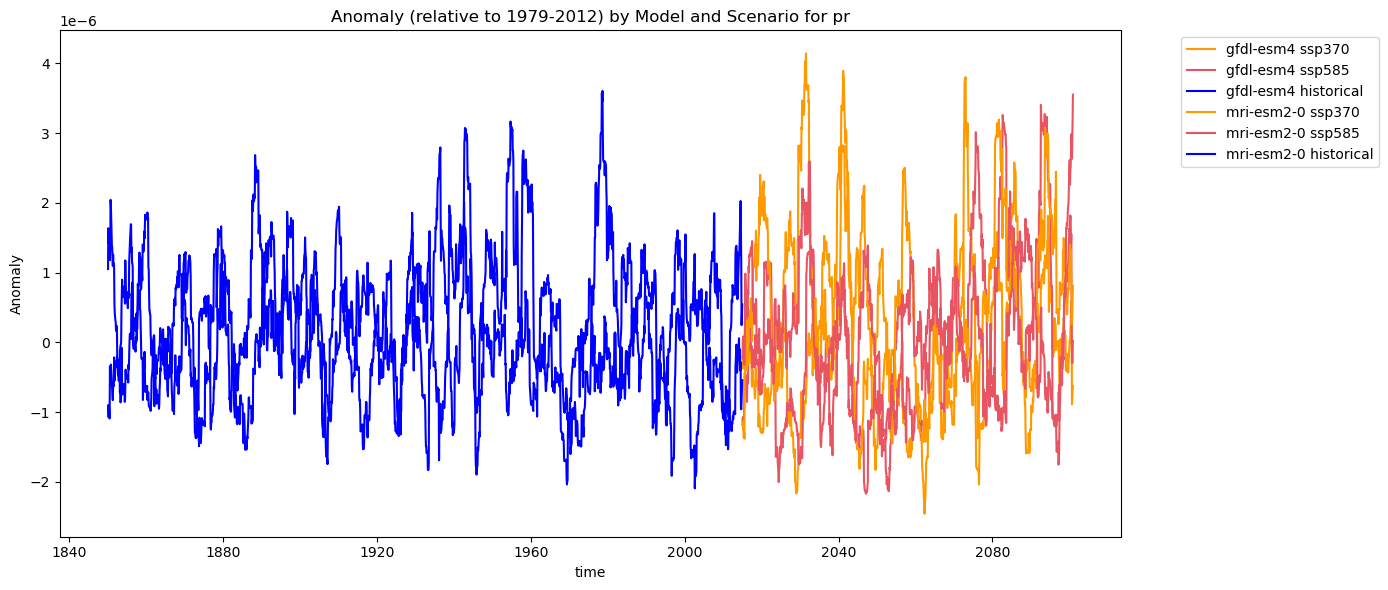

<bound method ClimateFutures.classify of <__main__.ClimateFutures object at 0x7fffb9c24470>>


In [58]:
cf = ClimateFutures(
    models=['gfdl-esm4_r1i1p1f1', 'mri-esm2-0_r1i1p1f1'],
    scenarios=['ssp370', 'ssp585', 'historical'],
    park='jotr',
    baseline_period=("1979", "2012")
)
cf.plot_ensemble('pr')
df = cf.classify
print(df)